In [15]:
# # disable numba njit with os
# import os
# os.environ["NUMBA_DISABLE_JIT"] = "1"

In [1]:
from ler.gw_source_population import CBCSourceParameterDistribution
import numpy as np
import matplotlib.pyplot as plt

create_new = True
cbc = CBCSourceParameterDistribution(
    create_new_interpolator=dict(
            mass_1_source=dict(create_new=create_new, resolution=200),
            mass_2_source=dict(create_new=create_new, resolution=200),
            mass_ratio=dict(create_new=create_new, resolution=100, m1_resolution=200),
    ),
)


Initializing CBCSourceRedshiftDistribution class...

luminosity_distance interpolator will be loaded from ./interpolator_json/luminosity_distance/luminosity_distance_0.json
differential_comoving_volume interpolator will be loaded from ./interpolator_json/differential_comoving_volume/differential_comoving_volume_0.json
using ler available merger rate density model: merger_rate_density_madau_dickinson_belczynski_ng
merger_rate_density_madau_dickinson_belczynski_ng interpolator will be generated at ./interpolator_json/merger_rate_density/merger_rate_density_madau_dickinson_belczynski_ng_0.json
merger_rate_density_madau_dickinson_belczynski_ng_detector_frame interpolator will be generated at ./interpolator_json/merger_rate_density/merger_rate_density_madau_dickinson_belczynski_ng_detector_frame_1.json
source_redshift interpolator will be generated at ./interpolator_json/source_redshift/source_redshift_0.json

Initializing CBCSourceParameterDistribution class...

using ler available zs fun

In [2]:
# cbc.available_gw_prior.keys()
for key, value1 in cbc.available_gw_prior.items():
    print(f"{key}: ")
    for key2, value2 in value1.items():
        print(f"\t{key2}: {value2}")

merger_rate_density: 
	merger_rate_density_madau_dickinson_belczynski_ng: {'param_name': 'merger_rate_density', 'function_type': 'merger_rate_density_madau_dickinson_belczynski_ng', 'R0': 1.9e-08, 'alpha_F': 2.57, 'beta_F': 5.83, 'c_F': 3.36}
	merger_rate_density_bbh_oguri2018: {'param_name': 'merger_rate_density', 'function_type': 'merger_rate_density_bbh_oguri2018', 'R0': 1.9e-08, 'b2': 1.6, 'b3': 2.1, 'b4': 30}
	merger_rate_density_madau_dickinson2014: {'param_name': 'merger_rate_density', 'function_type': 'merger_rate_density_madau_dickinson2014', 'R0': 8.9e-08, 'a': 0.015, 'b': 2.7, 'c': 2.9, 'd': 5.6}
	sfr_with_time_delay: {'param_name': 'merger_rate_density', 'function_type': 'sfr_with_time_delay', 'R0': 1.9e-08, 'a': 0.01, 'b': 2.6, 'c': 3.2, 'd': 6.2, 'td_min': 0.01, 'td_max': 10.0}
	merger_rate_density_bbh_popIII_ken2022: {'param_name': 'merger_rate_density', 'function_type': 'merger_rate_density_bbh_popIII_ken2022', 'R0': 1.92e-08, 'aIII': 0.66, 'bIII': 0.3, 'zIII': 11.6}
	m

## BBH Primary Mass: Broken Power Law + Two Gaussian Peaks

* GWTC-4 population fitting

In [4]:
mlow_1 = 5.059
m1_arr = np.geomspace(mlow_1, 100.0, 200)
fn_m1 = cbc.mass_1_source.function(m1_arr)

In [5]:
size = 20000
m1_samples = cbc.mass_1_source.rvs(size)

In [6]:
q_arr = cbc.mass_ratio.rvs(size, m1_samples)
m2_samples = q_arr * m1_samples

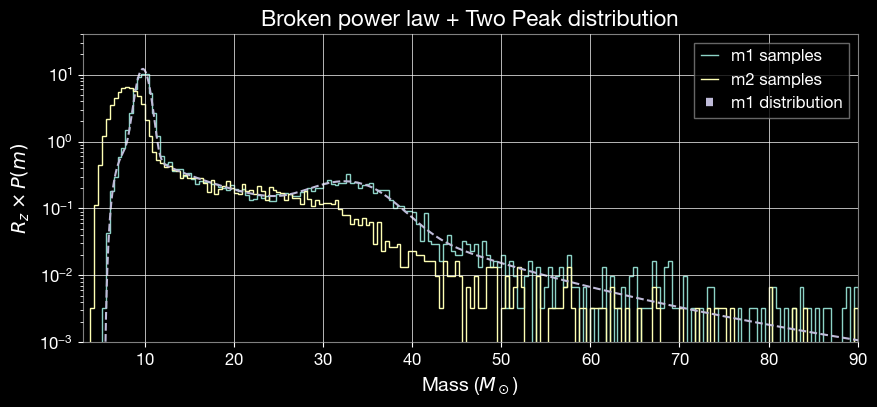

In [7]:
# rate
R0=16.158
kappa=3.166 
z_eval=0.2
R_z = R0 * (1.0 + z_eval) ** kappa

bins = np.linspace(3, 90, 201)

# Density histograms
m1_pdf, edges = np.histogram(m1_samples, bins=bins, density=True)
m2_pdf, _ = np.histogram(m2_samples, bins=bins, density=True)

# Scale each bin by rate
m1_rate = R_z * m1_pdf
m2_rate = R_z * m2_pdf

plt.figure(figsize=(10, 4))
plt.stairs(m1_rate, edges, label='m1 samples')
plt.stairs(m2_rate, edges, label='m2 samples')
plt.plot(m1_arr, fn_m1, '--', label='m1 distribution')
plt.title('Broken power law + Two Peak distribution', fontsize=16)
plt.xlabel('Mass ($M_\\odot$)', fontsize=14)
plt.ylabel(r'$R_z \times P(m)$', fontsize=14)
plt.yscale('log')
plt.ylim(1e-3, 40)
plt.xlim(3, 90)
plt.legend()
plt.show()

## Mass-ratio distribution

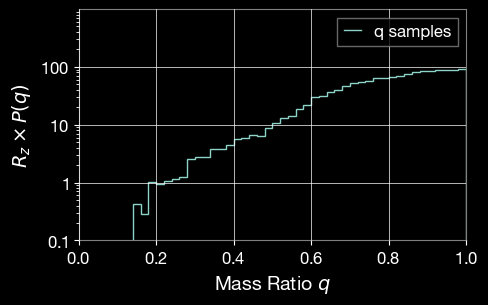

In [8]:
q_bins = np.linspace(0, 1, 51)
q_pdf, q_edges = np.histogram(q_arr, bins=q_bins, density=True)
# rate
R0=16.158
kappa=3.166 
z_eval=0.2
R_z = R0 * (1.0 + z_eval) ** kappa
q_rate = R_z * q_pdf

plt.figure(figsize=(5, 3))
plt.stairs(q_rate, q_edges, label='q samples')
plt.xlabel('Mass Ratio $q$', fontsize=14)
plt.ylabel('$R_z \\times P(q)$', fontsize=14)
plt.yscale('log')
plt.ylim(1e-1, 1e3-10)
plt.xlim(0, 1)
plt.legend()
plt.show()

## BBH Primary Mass: Power law + Peak distribution

* GWTC-3 population fitting

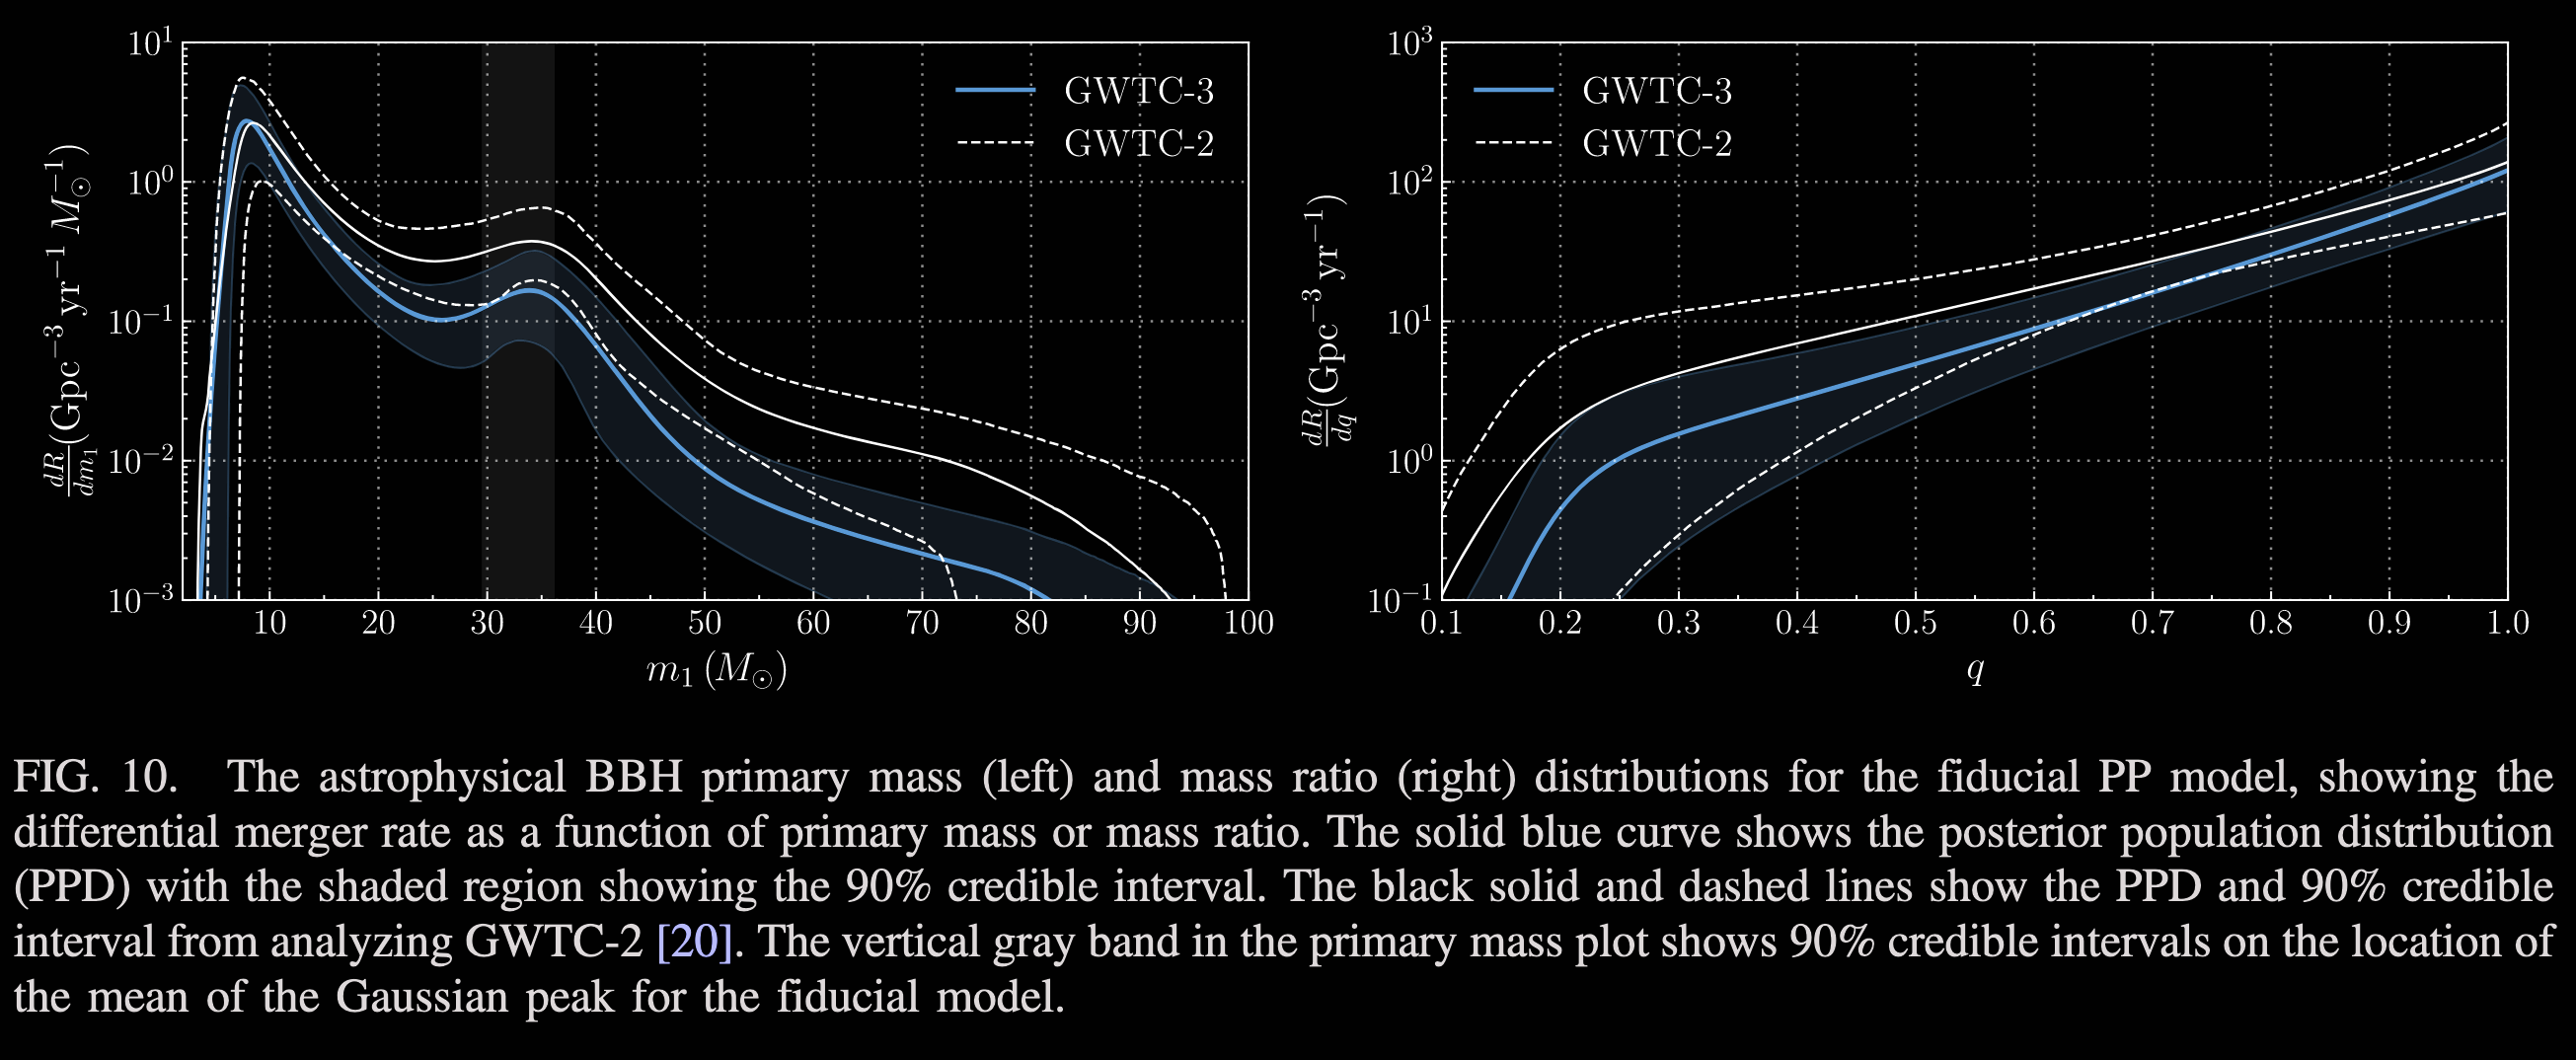

In [9]:
from ler.gw_source_population import CBCSourceParameterDistribution
import numpy as np
import matplotlib.pyplot as plt

create_new = True
cbc = CBCSourceParameterDistribution(
    gw_priors=dict(
        mass_1_source="powerlaw_plus_peak"
    ),
    create_new_interpolator=dict(
            mass_1_source=dict(create_new=create_new, resolution=200),
            mass_2_source=dict(create_new=create_new, resolution=200),
            mass_ratio=dict(create_new=create_new, resolution=100, m1_resolution=200),
    ),
)


Initializing CBCSourceRedshiftDistribution class...

luminosity_distance interpolator will be loaded from ./interpolator_json/luminosity_distance/luminosity_distance_0.json
differential_comoving_volume interpolator will be loaded from ./interpolator_json/differential_comoving_volume/differential_comoving_volume_0.json
using ler available merger rate density model: merger_rate_density_madau_dickinson_belczynski_ng
merger_rate_density_madau_dickinson_belczynski_ng interpolator will be loaded from ./interpolator_json/merger_rate_density/merger_rate_density_madau_dickinson_belczynski_ng_0.json
merger_rate_density_madau_dickinson_belczynski_ng_detector_frame interpolator will be loaded from ./interpolator_json/merger_rate_density/merger_rate_density_madau_dickinson_belczynski_ng_detector_frame_1.json
source_redshift interpolator will be loaded from ./interpolator_json/source_redshift/source_redshift_0.json

Initializing CBCSourceParameterDistribution class...

using ler available zs functi

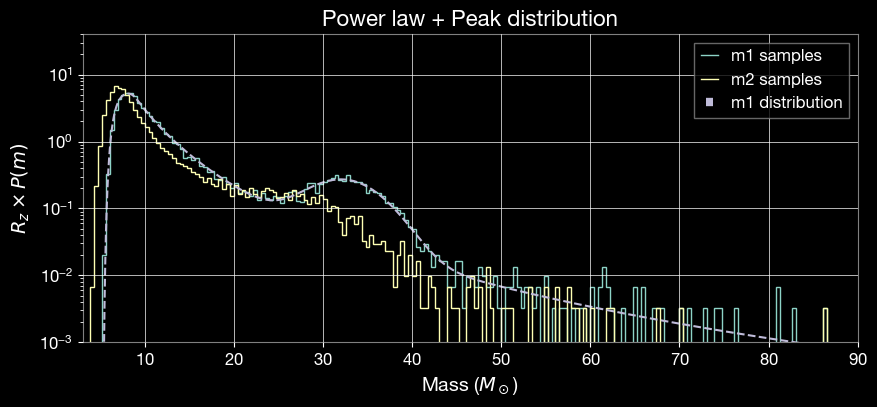

In [10]:
mlow_1 = 5.059
m1_arr = np.geomspace(mlow_1, 100.0, 200)
fn_m1 = cbc.mass_1_source.function(m1_arr)

size = 20000
m1_samples = cbc.mass_1_source.rvs(size)

q_arr = cbc.mass_ratio.rvs(size, m1_samples)
m2_samples = q_arr * m1_samples

# rate
R0=16.158
kappa=3.166 
z_eval=0.2
R_z = R0 * (1.0 + z_eval) ** kappa

bins = np.linspace(3, 90, 201)

# Density histograms
m1_pdf, edges = np.histogram(m1_samples, bins=bins, density=True)
m2_pdf, _ = np.histogram(m2_samples, bins=bins, density=True)

# Scale each bin by rate
m1_rate = R_z * m1_pdf
m2_rate = R_z * m2_pdf

plt.figure(figsize=(10, 4))
plt.stairs(m1_rate, edges, label='m1 samples')
plt.stairs(m2_rate, edges, label='m2 samples')
plt.plot(m1_arr, fn_m1, '--', label='m1 distribution')
plt.title('Power law + Peak distribution', fontsize=16)
plt.xlabel('Mass ($M_\\odot$)', fontsize=14)
plt.ylabel(r'$R_z \times P(m)$', fontsize=14)
plt.yscale('log')
plt.ylim(1e-3, 40)
plt.xlim(3, 90)
plt.legend()
plt.show()

## BNS Primary Mass: Uniform distribution

In [11]:
from ler.gw_source_population import CBCSourceParameterDistribution
import numpy as np
import matplotlib.pyplot as plt

create_new = True
cbc = CBCSourceParameterDistribution(
    gw_priors=dict(
        mass_1_source="uniform",
        mass_ratio=None,
        mass_2_source="uniform",
    ),
    create_new_interpolator=dict(
            mass_1_source=dict(create_new=create_new, resolution=200),
            mass_2_source=dict(create_new=create_new, resolution=200),
            mass_ratio=dict(create_new=create_new, resolution=100, m1_resolution=200),
    ),
)


Initializing CBCSourceRedshiftDistribution class...

luminosity_distance interpolator will be loaded from ./interpolator_json/luminosity_distance/luminosity_distance_0.json
differential_comoving_volume interpolator will be loaded from ./interpolator_json/differential_comoving_volume/differential_comoving_volume_0.json
using ler available merger rate density model: merger_rate_density_madau_dickinson_belczynski_ng
merger_rate_density_madau_dickinson_belczynski_ng interpolator will be loaded from ./interpolator_json/merger_rate_density/merger_rate_density_madau_dickinson_belczynski_ng_0.json
merger_rate_density_madau_dickinson_belczynski_ng_detector_frame interpolator will be loaded from ./interpolator_json/merger_rate_density/merger_rate_density_madau_dickinson_belczynski_ng_detector_frame_1.json
source_redshift interpolator will be loaded from ./interpolator_json/source_redshift/source_redshift_0.json

Initializing CBCSourceParameterDistribution class...

using ler available zs functi

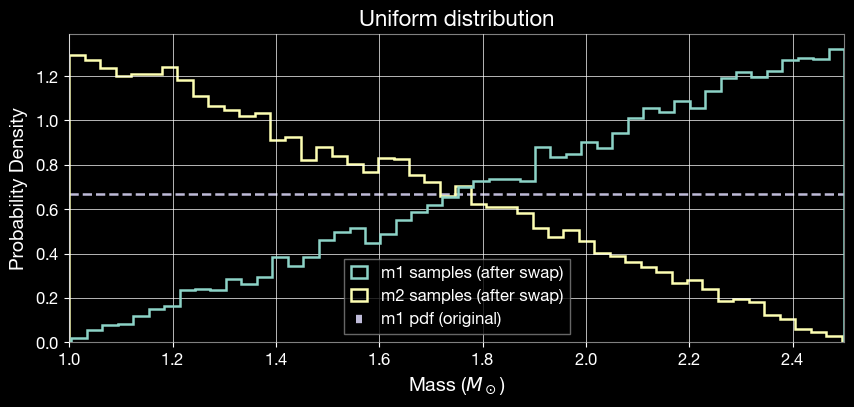

In [12]:
mmin = 1.0
mmax = 2.5

size = 20000
m1_samples = cbc.mass_1_source.rvs(size)
m2_samples = cbc.mass_2_source.rvs(size)

# swap m1 and m2 if m2 > m1
swap_indices = m2_samples > m1_samples
m1_samples[swap_indices], m2_samples[swap_indices] = m2_samples[swap_indices], m1_samples[swap_indices]

# The reference model is evaluated on the plotted mass range
m1_arr = np.linspace(mmin, mmax, 300)
m1_pdf_original = cbc.mass_1_source.pdf(m1_arr)

plt.figure(figsize=(10, 4))
plt.hist(m1_samples, bins=50, density=True, histtype='step', label='m1 samples (after swap)', linewidth=1.8, zorder=3)
plt.hist(m2_samples, bins=50, density=True, histtype='step', label='m2 samples (after swap)', linewidth=1.8, zorder=2)
plt.plot(m1_arr, m1_pdf_original, '--', label='m1 pdf (original)', linewidth=1.8, zorder=1)
plt.title('Uniform distribution', fontsize=16)
plt.xlabel('Mass ($M_\\odot$)', fontsize=14)
plt.ylabel('Probability Density', fontsize=14)
plt.xlim(mmin, mmax)
plt.ylim(bottom=0)
plt.legend()
plt.show()

## BNS Primary Mass: Powerlaw distribution

In [13]:
from ler.gw_source_population import CBCSourceParameterDistribution
import numpy as np
import matplotlib.pyplot as plt

create_new = True
cbc = CBCSourceParameterDistribution(
    gw_priors=dict(
        mass_1_source="powerlaw",
        mass_ratio=None,
        mass_2_source="powerlaw",
    ),
    create_new_interpolator=dict(
            mass_1_source=dict(create_new=create_new, resolution=200),
            mass_2_source=dict(create_new=create_new, resolution=200),
            mass_ratio=dict(create_new=create_new, resolution=100, m1_resolution=200),
    ),
)


Initializing CBCSourceRedshiftDistribution class...

luminosity_distance interpolator will be loaded from ./interpolator_json/luminosity_distance/luminosity_distance_0.json
differential_comoving_volume interpolator will be loaded from ./interpolator_json/differential_comoving_volume/differential_comoving_volume_0.json
using ler available merger rate density model: merger_rate_density_madau_dickinson_belczynski_ng
merger_rate_density_madau_dickinson_belczynski_ng interpolator will be loaded from ./interpolator_json/merger_rate_density/merger_rate_density_madau_dickinson_belczynski_ng_0.json
merger_rate_density_madau_dickinson_belczynski_ng_detector_frame interpolator will be loaded from ./interpolator_json/merger_rate_density/merger_rate_density_madau_dickinson_belczynski_ng_detector_frame_1.json
source_redshift interpolator will be loaded from ./interpolator_json/source_redshift/source_redshift_0.json

Initializing CBCSourceParameterDistribution class...

using ler available zs functi

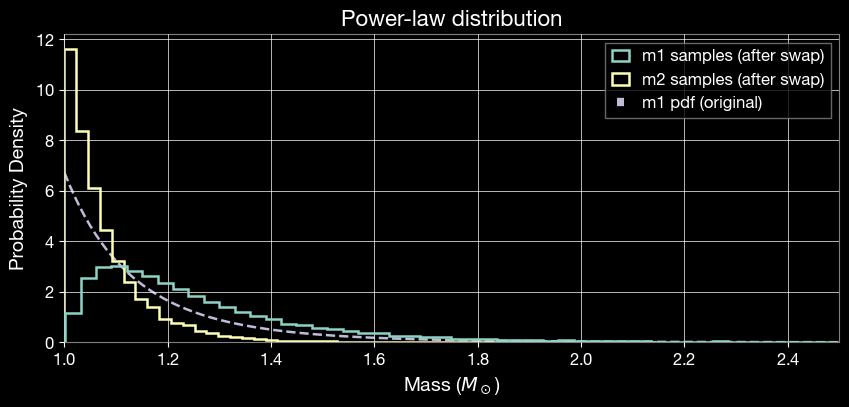

In [14]:
mmin = 1.0
mmax = 2.5

size = 20000
m1_samples = cbc.mass_1_source.rvs(size)
m2_samples = cbc.mass_2_source.rvs(size)

# swap m1 and m2 if m2 > m1
swap_indices = m2_samples > m1_samples
m1_samples[swap_indices], m2_samples[swap_indices] = m2_samples[swap_indices], m1_samples[swap_indices]

# The reference model is evaluated on the plotted mass range
m1_arr = np.linspace(mmin, mmax, 300)
m1_pdf_original = cbc.mass_1_source.pdf(m1_arr)

plt.figure(figsize=(10, 4))
plt.hist(m1_samples, bins=50, density=True, histtype='step', label='m1 samples (after swap)', linewidth=1.8, zorder=3)
plt.hist(m2_samples, bins=50, density=True, histtype='step', label='m2 samples (after swap)', linewidth=1.8, zorder=2)
plt.plot(m1_arr, m1_pdf_original, '--', label='m1 pdf (original)', linewidth=1.8, zorder=1)
plt.title('Power-law distribution', fontsize=16)
plt.xlabel('Mass ($M_\\odot$)', fontsize=14)
plt.ylabel('Probability Density', fontsize=14)
plt.xlim(mmin, mmax)
plt.ylim(bottom=0)
plt.legend()
plt.show()

## BNS Primary Mass: Truncated Normal distribution

In [15]:
from ler.gw_source_population import CBCSourceParameterDistribution
import numpy as np
import matplotlib.pyplot as plt

create_new = True
cbc = CBCSourceParameterDistribution(
    gw_priors=dict(
        mass_1_source="truncated_normal",
        mass_ratio=None,
        mass_2_source="truncated_normal",
    ),
    create_new_interpolator=dict(
            mass_1_source=dict(create_new=create_new, resolution=200),
            mass_2_source=dict(create_new=create_new, resolution=200),
            mass_ratio=dict(create_new=create_new, resolution=100, m1_resolution=200),
    ),
)


Initializing CBCSourceRedshiftDistribution class...

luminosity_distance interpolator will be loaded from ./interpolator_json/luminosity_distance/luminosity_distance_0.json
differential_comoving_volume interpolator will be loaded from ./interpolator_json/differential_comoving_volume/differential_comoving_volume_0.json
using ler available merger rate density model: merger_rate_density_madau_dickinson_belczynski_ng
merger_rate_density_madau_dickinson_belczynski_ng interpolator will be loaded from ./interpolator_json/merger_rate_density/merger_rate_density_madau_dickinson_belczynski_ng_0.json
merger_rate_density_madau_dickinson_belczynski_ng_detector_frame interpolator will be loaded from ./interpolator_json/merger_rate_density/merger_rate_density_madau_dickinson_belczynski_ng_detector_frame_1.json
source_redshift interpolator will be loaded from ./interpolator_json/source_redshift/source_redshift_0.json

Initializing CBCSourceParameterDistribution class...

using ler available zs functi

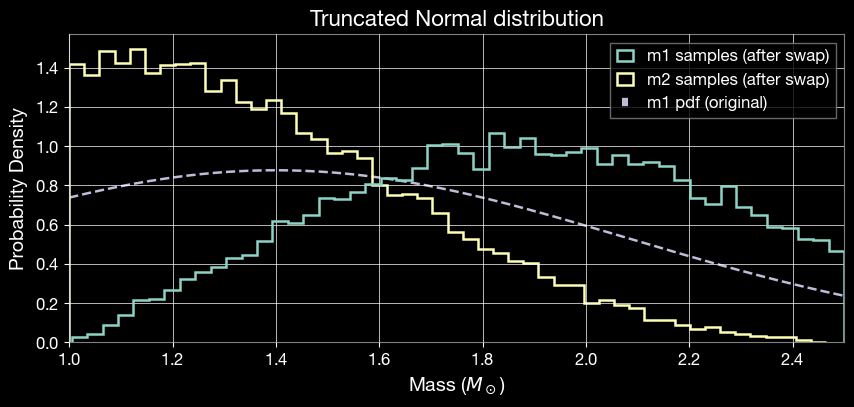

In [16]:
mmin = 1.0
mmax = 2.5

size = 20000
m1_samples = cbc.mass_1_source.rvs(size)
m2_samples = cbc.mass_2_source.rvs(size)

# swap m1 and m2 if m2 > m1
swap_indices = m2_samples > m1_samples
m1_samples[swap_indices], m2_samples[swap_indices] = m2_samples[swap_indices], m1_samples[swap_indices]

# The reference model is evaluated on the plotted mass range
m1_arr = np.linspace(mmin, mmax, 300)
m1_pdf_original = cbc.mass_1_source.pdf(m1_arr)

plt.figure(figsize=(10, 4))
plt.hist(m1_samples, bins=50, density=True, histtype='step', label='m1 samples (after swap)', linewidth=1.8, zorder=3)
plt.hist(m2_samples, bins=50, density=True, histtype='step', label='m2 samples (after swap)', linewidth=1.8, zorder=2)
plt.plot(m1_arr, m1_pdf_original, '--', label='m1 pdf (original)', linewidth=1.8, zorder=1)
plt.title('Truncated Normal distribution', fontsize=16)
plt.xlabel('Mass ($M_\\odot$)', fontsize=14)
plt.ylabel('Probability Density', fontsize=14)
plt.xlim(mmin, mmax)
plt.ylim(bottom=0)
plt.legend()
plt.show()

## BNS Primary Mass: Bimodal distribution

In [17]:
from ler.gw_source_population import CBCSourceParameterDistribution
import numpy as np
import matplotlib.pyplot as plt

create_new = True
cbc = CBCSourceParameterDistribution(
    gw_priors=dict(
        mass_1_source="bimodal",
        mass_ratio=None,
        mass_2_source="bimodal",
    ),
    create_new_interpolator=dict(
            mass_1_source=dict(create_new=create_new, resolution=200),
            mass_2_source=dict(create_new=create_new, resolution=200),
            mass_ratio=dict(create_new=create_new, resolution=100, m1_resolution=200),
    ),
)


Initializing CBCSourceRedshiftDistribution class...

luminosity_distance interpolator will be loaded from ./interpolator_json/luminosity_distance/luminosity_distance_0.json
differential_comoving_volume interpolator will be loaded from ./interpolator_json/differential_comoving_volume/differential_comoving_volume_0.json
using ler available merger rate density model: merger_rate_density_madau_dickinson_belczynski_ng
merger_rate_density_madau_dickinson_belczynski_ng interpolator will be loaded from ./interpolator_json/merger_rate_density/merger_rate_density_madau_dickinson_belczynski_ng_0.json
merger_rate_density_madau_dickinson_belczynski_ng_detector_frame interpolator will be loaded from ./interpolator_json/merger_rate_density/merger_rate_density_madau_dickinson_belczynski_ng_detector_frame_1.json
source_redshift interpolator will be loaded from ./interpolator_json/source_redshift/source_redshift_0.json

Initializing CBCSourceParameterDistribution class...

using ler available zs functi

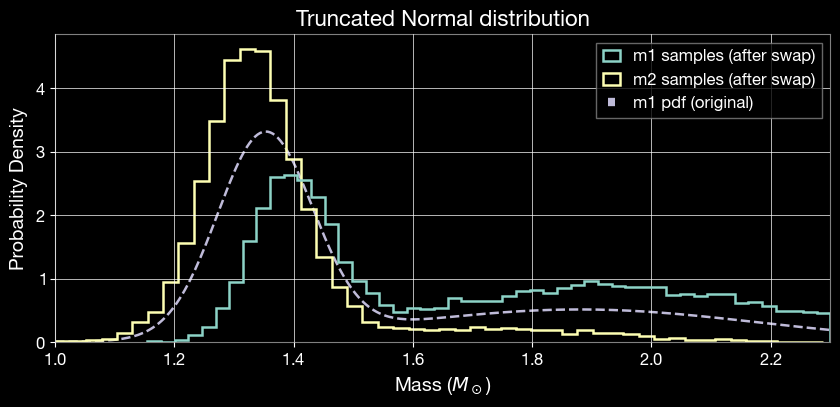

In [ ]:
mmin = 1.0
mmax = 2.3

size = 20000
m1_samples = cbc.mass_1_source.rvs(size)
m2_samples = cbc.mass_2_source.rvs(size)

# swap m1 and m2 if m2 > m1
swap_indices = m2_samples > m1_samples
m1_samples[swap_indices], m2_samples[swap_indices] = m2_samples[swap_indices], m1_samples[swap_indices]

# The reference model is evaluated on the plotted mass range
m1_arr = np.linspace(mmin, mmax, 300)
m1_pdf_original = cbc.mass_1_source.pdf(m1_arr)

plt.figure(figsize=(10, 4))
plt.hist(m1_samples, bins=50, density=True, histtype='step', label='m1 samples (after swap)', linewidth=1.8, zorder=3)
plt.hist(m2_samples, bins=50, density=True, histtype='step', label='m2 samples (after swap)', linewidth=1.8, zorder=2)
plt.plot(m1_arr, m1_pdf_original, '--', label='m1 pdf (original)', linewidth=1.8, zorder=1)
plt.title('Bimodal distribution', fontsize=16)
plt.xlabel('Mass ($M_\\odot$)', fontsize=14)
plt.ylabel('Probability Density', fontsize=14)
plt.xlim(mmin, mmax)
plt.ylim(bottom=0)
plt.legend()
plt.show()

## NSBH

In [1]:
from ler.gw_source_population import CBCSourceParameterDistribution
import numpy as np
import matplotlib.pyplot as plt

create_new = True
cbc = CBCSourceParameterDistribution(
    event_type="NSBH",
    create_new_interpolator=dict(
            mass_1_source=dict(create_new=create_new, resolution=200),
            mass_2_source=dict(create_new=create_new, resolution=200),
            mass_ratio=dict(create_new=create_new, resolution=100, m1_resolution=200),
    ),
)


Initializing CBCSourceRedshiftDistribution class...

luminosity_distance interpolator will be loaded from ./interpolator_json/luminosity_distance/luminosity_distance_0.json
differential_comoving_volume interpolator will be loaded from ./interpolator_json/differential_comoving_volume/differential_comoving_volume_0.json
using ler available merger rate density model: merger_rate_density_madau_dickinson2014
merger_rate_density_madau_dickinson2014 interpolator will be generated at ./interpolator_json/merger_rate_density/merger_rate_density_madau_dickinson2014_2.json
merger_rate_density_madau_dickinson2014_detector_frame interpolator will be generated at ./interpolator_json/merger_rate_density/merger_rate_density_madau_dickinson2014_detector_frame_3.json
source_redshift interpolator will be generated at ./interpolator_json/source_redshift/source_redshift_1.json

Initializing CBCSourceParameterDistribution class...

using ler available zs function : source_redshift
using ler available mass_1

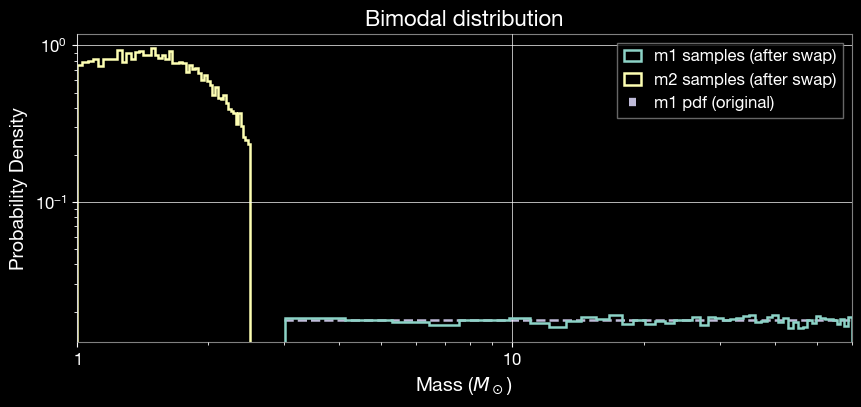

In [3]:
mmin = 3.0
mmax = 60.0

size = 20000
m1_samples = cbc.mass_1_source.rvs(size)
m2_samples = cbc.mass_2_source.rvs(size)

# swap m1 and m2 if m2 > m1
swap_indices = m2_samples > m1_samples
m1_samples[swap_indices], m2_samples[swap_indices] = m2_samples[swap_indices], m1_samples[swap_indices]

# The reference model is evaluated on the plotted mass range
m1_arr = np.linspace(mmin, mmax, 300)
m1_pdf_original = cbc.mass_1_source.pdf(m1_arr)

plt.figure(figsize=(10, 4))
plt.hist(m1_samples, bins=50, density=True, histtype='step', label='m1 samples (after swap)', linewidth=1.8, zorder=3)
plt.hist(m2_samples, bins=50, density=True, histtype='step', label='m2 samples (after swap)', linewidth=1.8, zorder=2)
plt.plot(m1_arr, m1_pdf_original, '--', label='m1 pdf (original)', linewidth=1.8, zorder=1)
plt.title('Bimodal distribution', fontsize=16)
plt.xlabel('Mass ($M_\\odot$)', fontsize=14)
plt.ylabel('Probability Density', fontsize=14)
plt.yscale('log')
plt.xscale('log')
plt.xlim(1.0, mmax)
plt.ylim(bottom=0)
plt.legend()
plt.show()